# Classical Forecasting Methods

Classical statistical methods form the backbone of time series forecasting. They are interpretable, fast, and often competitive with deep learning on short/medium series.

## Overview of Methods

| Method | Best For | Key Assumption |
|--------|----------|----------------|
| Moving Average | Smoothing, simple forecast | No trend/seasonality |
| Exponential Smoothing | Short-term, trending series | Weighted recent observations |
| ARIMA | Stationary/differenced series | Linear, no seasonality |
| SARIMA | Seasonal series | Linear + seasonal |
| VAR | Multiple interrelated series | Multivariate linear |

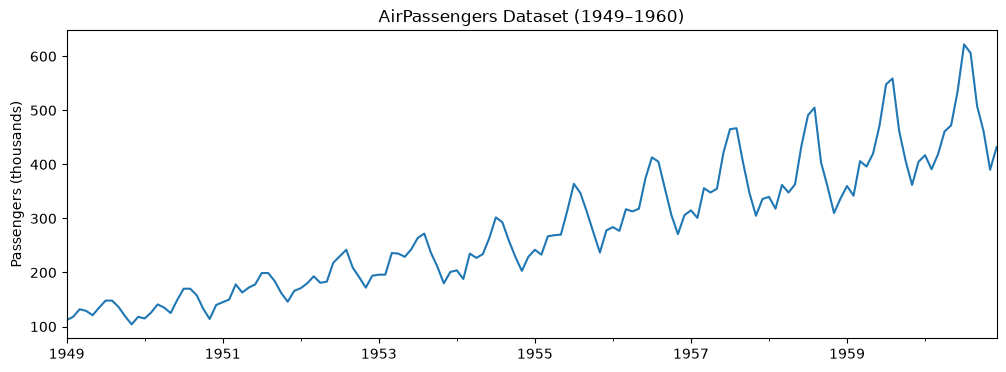

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load AirPassengers dataset (classic benchmark)
from statsmodels.datasets import get_rdataset
data = get_rdataset('AirPassengers').data
data.index = pd.date_range(start='1949-01', periods=len(data), freq='MS')
series = data['value']

series.plot(figsize=(12, 4), title='AirPassengers Dataset (1949-1960)', ylabel='Passengers (thousands)')
plt.show()

## Moving Averages

### Simple Moving Average (SMA)
$$\hat{Y}_{t+1} = \frac{1}{k} \sum_{i=0}^{k-1} Y_{t-i} = \frac{Y_t + Y_{t-1} + \ldots + Y_{t-k+1}}{k}$$

### Weighted Moving Average (WMA)
$$\hat{Y}_{t+1} = \sum_{i=0}^{k-1} w_i Y_{t-i}, \quad \sum_{i=0}^{k-1} w_i = 1$$

### Exponentially Weighted Moving Average (EWMA)
$$\hat{Y}_{t+1} = \alpha Y_t + (1-\alpha)\hat{Y}_t, \quad 0 < \alpha \leq 1$$

Expanding the recursion:
$$\hat{Y}_{t+1} = \alpha \sum_{j=0}^{\infty} (1-\alpha)^j Y_{t-j}$$

Weights decay geometrically recent observations get higher weight.

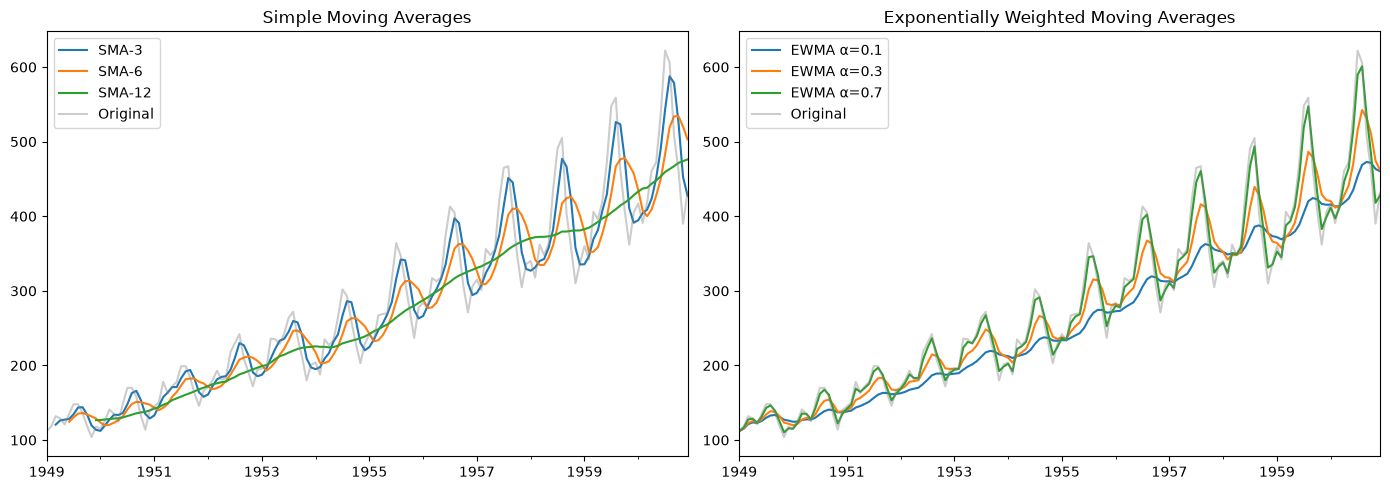

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SMA
for k in [3, 6, 12]:
    series.rolling(k).mean().plot(ax=axes[0], label=f'SMA-{k}')
series.plot(ax=axes[0], label='Original', alpha=0.4, color='gray')
axes[0].set_title('Simple Moving Averages')
axes[0].legend()

# EWMA
for alpha in [0.1, 0.3, 0.7]:
    series.ewm(alpha=alpha).mean().plot(ax=axes[1], label=f'EWMA α={alpha}')
series.plot(ax=axes[1], label='Original', alpha=0.4, color='gray')
axes[1].set_title('Exponentially Weighted Moving Averages')
axes[1].legend()

plt.tight_layout()
plt.show()

## Exponential Smoothing Family

### 1. Simple Exponential Smoothing (SES)
No trend, no seasonality. Optimal for stationary series.

$$\ell_t = \alpha y_t + (1 - \alpha) \ell_{t-1}$$
$$\hat{y}_{t+h} = \ell_t \quad \forall h \geq 1$$

### 2. Holt's Linear (Double Exponential Smoothing)
Handles **trend** but not seasonality.

**Level:**
$$\ell_t = \alpha y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1})$$
**Trend:**
$$b_t = \beta^*(\ell_t - \ell_{t-1}) + (1 - \beta^*) b_{t-1}$$
**Forecast:**
$$\hat{y}_{t+h} = \ell_t + h \cdot b_t$$

Parameters: $\alpha \in (0,1)$, $\beta^* \in (0,1)$

### 3. Holt-Winters (Triple Exponential Smoothing)
Handles **trend + seasonality**.

**Additive version** (constant seasonal variation):

$$\ell_t = \alpha (y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*) b_{t-1}$$
$$s_t = \gamma(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}$$
$$\hat{y}_{t+h} = \ell_t + h \cdot b_t + s_{t+h-m(\lfloor(h-1)/m\rfloor+1)}$$

**Multiplicative version** (seasonal variation grows with level):

$$\ell_t = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*) b_{t-1}$$
$$s_t = \gamma \frac{y_t}{\ell_{t-1} + b_{t-1}} + (1-\gamma)s_{t-m}$$
$$\hat{y}_{t+h} = (\ell_t + h \cdot b_t) \cdot s_{t+h-m(\lfloor(h-1)/m\rfloor+1)}$$

Parameters: $\alpha, \beta^*, \gamma \in (0,1)$, $m$ = seasonal period

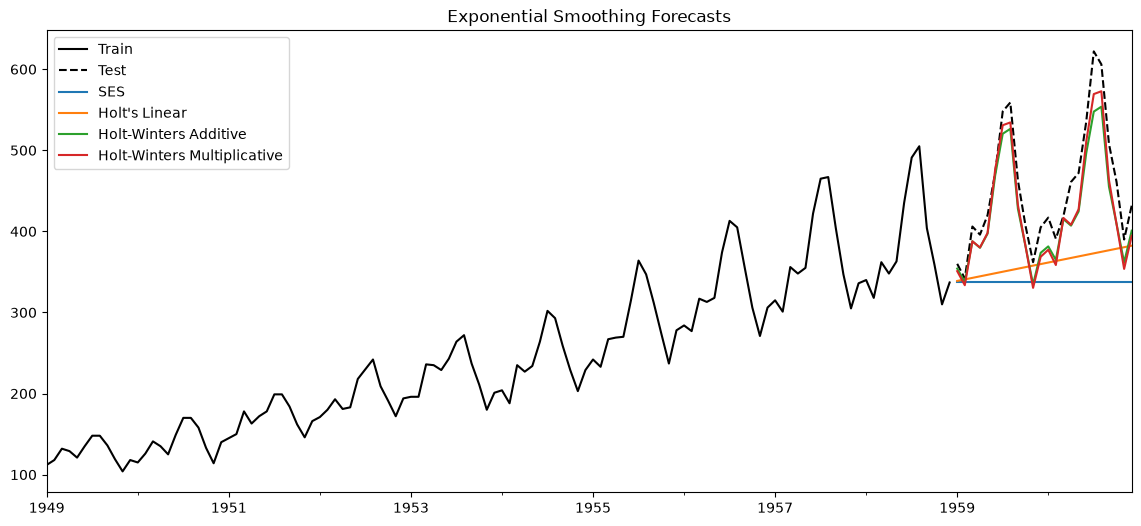

SES      | MAE=115.25 | RMSE=137.33 | MAPE=23.58%
Holt     | MAE=91.62 | RMSE=115.70 | MAPE=18.41%
HW-Add   | MAE=31.08 | RMSE=35.76 | MAPE=6.64%
HW-Mul   | MAE=28.98 | RMSE=32.49 | MAPE=6.39%


In [3]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

train = series[:'1958']
test  = series['1959':]

# SES
ses = SimpleExpSmoothing(train).fit(optimized=True)
fc_ses = ses.forecast(len(test))

# Holt's Linear
holt = ExponentialSmoothing(train, trend='add').fit(optimized=True)
fc_holt = holt.forecast(len(test))

# Holt-Winters Additive
hw_add = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
fc_hw_add = hw_add.forecast(len(test))

# Holt-Winters Multiplicative (better for AirPassengers variance grows)
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit(optimized=True)
fc_hw_mul = hw_mul.forecast(len(test))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
train.plot(ax=ax, label='Train', color='black')
test.plot(ax=ax, label='Test', color='black', linestyle='--')
fc_ses.plot(ax=ax, label='SES')
fc_holt.plot(ax=ax, label="Holt's Linear")
fc_hw_add.plot(ax=ax, label='Holt-Winters Additive')
fc_hw_mul.plot(ax=ax, label='Holt-Winters Multiplicative')
ax.legend()
ax.set_title('Exponential Smoothing Forecasts')
plt.show()

# Error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
for name, fc in [('SES', fc_ses), ('Holt', fc_holt), ('HW-Add', fc_hw_add), ('HW-Mul', fc_hw_mul)]:
    mae  = mean_absolute_error(test, fc)
    rmse = np.sqrt(mean_squared_error(test, fc))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100
    print(f"{name:8s} | MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.2f}%")

## ARIMA Models

### AR(p) Autoregressive Model
Current value is a linear combination of $p$ past values:
$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \phi_p Y_{t-p} + \epsilon_t$$

Using backshift operator $B$:
$$\Phi_p(B) Y_t = c + \epsilon_t, \quad \Phi_p(B) = 1 - \phi_1 B - \ldots - \phi_p B^p$$

**Stationarity condition:** Roots of $\Phi_p(B) = 0$ must lie outside the unit circle.

### MA(q) Moving Average Model
Current value is a linear combination of $q$ past errors:
$$Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \ldots + \theta_q \epsilon_{t-q}$$

$$Y_t = \mu + \Theta_q(B) \epsilon_t, \quad \Theta_q(B) = 1 + \theta_1 B + \ldots + \theta_q B^q$$

### ARMA(p, q)
Combines AR and MA:
$$\Phi_p(B) Y_t = c + \Theta_q(B) \epsilon_t$$

### ARIMA(p, d, q)
Adds $d$ rounds of **differencing** to handle non-stationarity:
$$\Phi_p(B)(1-B)^d Y_t = c + \Theta_q(B) \epsilon_t$$

| Parameter | Meaning |
|-----------|--------|
| $p$ | AR order lags of $Y$ |
| $d$ | Degree of differencing |
| $q$ | MA order lags of $\epsilon$ |

### SARIMA(p, d, q)(P, D, Q)$_s$
Adds seasonal AR, differencing, and MA:
$$\Phi_P(B^s) \Phi_p(B)(1-B^s)^D (1-B)^d Y_t = \Theta_Q(B^s) \Theta_q(B) \epsilon_t$$

### Model Selection: AIC and BIC
$$\text{AIC} = 2k - 2\ln(\hat{L})$$
$$\text{BIC} = k \ln(n) - 2\ln(\hat{L})$$

where $k$ = number of parameters, $\hat{L}$ = maximum likelihood, $n$ = sample size. **Lower is better.**

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Log-transform AirPassengers (multiplicative seasonality → additive after log)
log_series = np.log(series)
log_train  = log_series[:'1958']
log_test   = log_series['1959':]

# ARIMA(2,1,2) manual order selection
arima = ARIMA(log_train, order=(2, 1, 2)).fit()
print(arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 107.730
Date:                Fri, 19 Jun 2026   AIC                           -205.461
Time:                        14:31:04   BIC                           -191.565
Sample:                    01-01-1949   HQIC                          -199.818
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2556      0.191      1.336      0.181      -0.119       0.630
ar.L2          0.2383      0.237      1.006      0.314      -0.226       0.702
ma.L1         -0.1103      0.142     -0.775      0.4

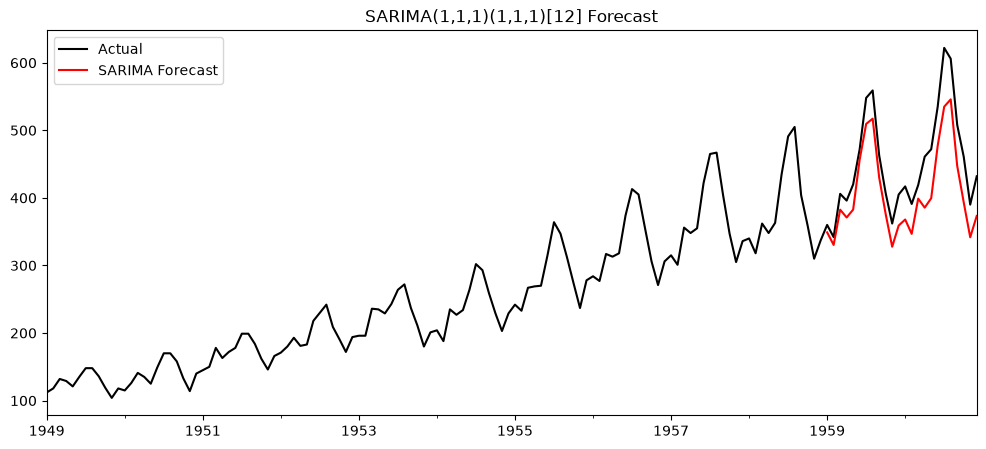

SARIMA | MAE=43.73 | MAPE=9.48%


In [5]:
# SARIMA(1,1,1)(1,1,1)[12] classic for monthly data
sarima = SARIMAX(log_train,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)

fc_sarima_log = sarima.forecast(steps=len(log_test))
fc_sarima = np.exp(fc_sarima_log)   # back-transform

fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, label='Actual', color='black')
fc_sarima.plot(ax=ax, label='SARIMA Forecast', color='red')
ax.set_title('SARIMA(1,1,1)(1,1,1)[12] Forecast')
ax.legend()
plt.show()

mae  = mean_absolute_error(test, fc_sarima)
mape = np.mean(np.abs((test.values - fc_sarima.values) / test.values)) * 100
print(f"SARIMA | MAE={mae:.2f} | MAPE={mape:.2f}%")

In [6]:
# Auto-ARIMA with pmdarima
try:
    import pmdarima as pm
    auto_model = pm.auto_arima(log_train,
                                seasonal=True, m=12,
                                stepwise=True,
                                information_criterion='aic',
                                trace=True)
    print(f"\nBest order: {auto_model.order}")
    print(f"Best seasonal order: {auto_model.seasonal_order}")
except ImportError:
    print("Install pmdarima: pip install pmdarima")

Install pmdarima: pip install pmdarima


## Residual Diagnostics

A well-fitted ARIMA model should have residuals that are **white noise**:
- Zero mean
- Constant variance
- No autocorrelation (Ljung-Box p > 0.05)
- Normally distributed

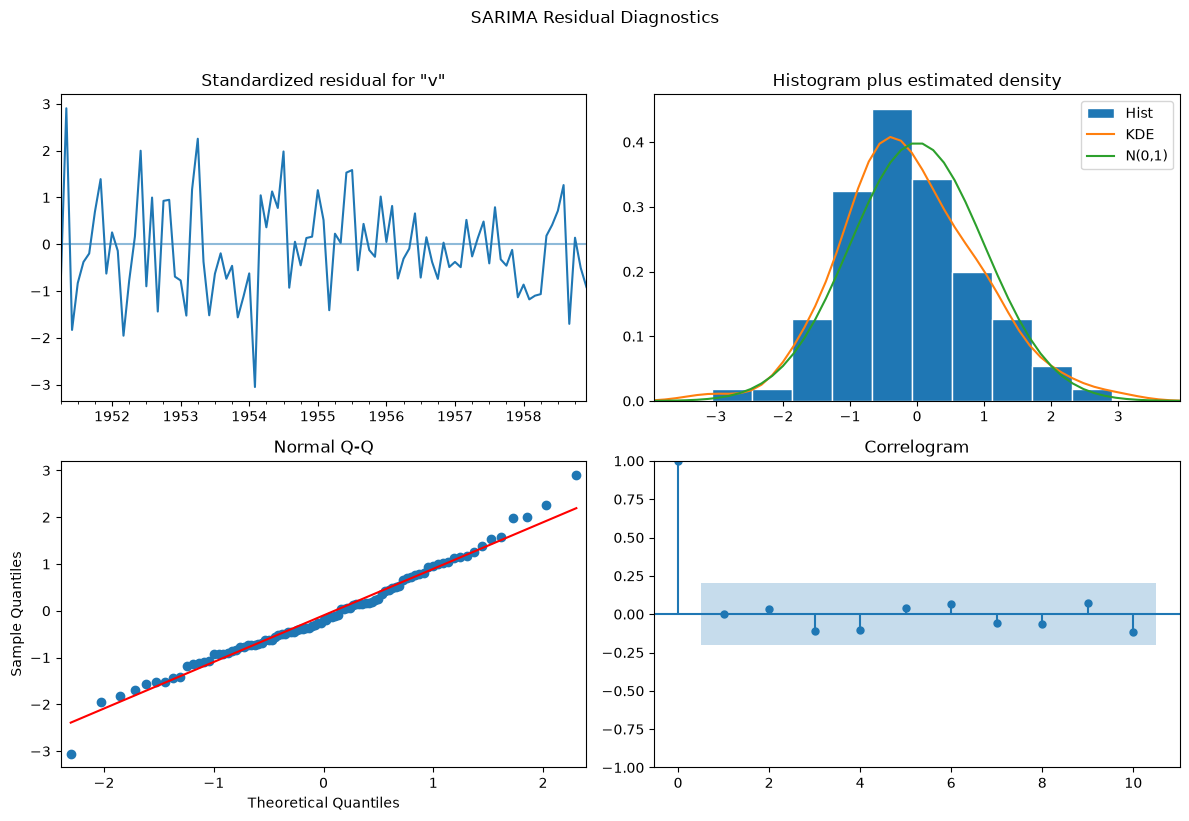

In [7]:
sarima.plot_diagnostics(figsize=(12, 8))
plt.suptitle('SARIMA Residual Diagnostics', y=1.02)
plt.tight_layout()
plt.show()

## SARIMAX With Exogenous Variables

Extends SARIMA with external regressors $\mathbf{x}_t$:
$$\Phi_P(B^s)\Phi_p(B)(1-B^s)^D(1-B)^d Y_t = \mathbf{x}_t'\boldsymbol{\beta} + \Theta_Q(B^s)\Theta_q(B)\epsilon_t$$

Example: forecasting sales with price and advertising spend as exogenous variables.

In [8]:
# Synthetic example: exogenous variable (e.g. promotion indicator)
np.random.seed(0)
promo = (np.random.rand(len(log_train)) > 0.8).astype(float)  # random promotions
promo_future = (np.random.rand(len(log_test)) > 0.8).astype(float)

sarimax = SARIMAX(log_train,
                  exog=promo.reshape(-1,1),
                  order=(1,1,1),
                  seasonal_order=(1,1,1,12),
                  enforce_stationarity=False).fit(disp=False)

print(f"Exogenous coefficient (promo): {sarimax.params['x1']:.4f}")

Exogenous coefficient (promo): -0.0007


/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## VAR Vector Autoregression

For **multiple interrelated time series** $\mathbf{y}_t = [y_{1,t}, y_{2,t}, \ldots, y_{K,t}]^T$:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \ldots + \mathbf{A}_p \mathbf{y}_{t-p} + \boldsymbol{\epsilon}_t$$

where $\mathbf{A}_i$ are $K \times K$ coefficient matrices.

Total parameters: $K^2 p + K$ grows quickly with $K$ and $p$.

In [9]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Load macroeconomic dataset
from statsmodels.datasets import macrodata
mdata = macrodata.load_pandas().data
mdata.index = pd.date_range('1959Q1', periods=len(mdata), freq='QS')
df_var = mdata[['realgdp', 'realcons', 'realinv']].apply(np.log).diff().dropna()

train_var = df_var.iloc[:-8]
test_var  = df_var.iloc[-8:]

# Fit VAR automatic lag selection
model_var = VAR(train_var)
lag_order = model_var.select_order(maxlags=8)
print("Lag selection:")
print(lag_order.summary())

var_fit = model_var.fit(maxlags=lag_order.aic)
fc_var  = var_fit.forecast(y=train_var.values[-lag_order.aic:], steps=8)
fc_df   = pd.DataFrame(fc_var, columns=df_var.columns)
print("\nVAR Forecast (first 3 steps):")
print(fc_df.head(3))

Lag selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -27.87      -27.82   7.880e-13      -27.85
1     -28.11*     -27.90*  6.219e-13*     -28.02*
2      -28.08      -27.72   6.385e-13      -27.93
3      -28.07      -27.55   6.470e-13      -27.86
4      -28.06      -27.38   6.522e-13      -27.79
5      -28.06      -27.23   6.516e-13      -27.72
6      -28.02      -27.03   6.781e-13      -27.62
7      -28.00      -26.86   6.912e-13      -27.54
8      -28.02      -26.72   6.833e-13      -27.49
-------------------------------------------------

VAR Forecast (first 3 steps):
    realgdp  realcons   realinv
0  0.004580  0.007385 -0.012483
1  0.007100  0.007916  0.005690
2  0.007628  0.008440  0.007425


## Box-Jenkins Methodology

The systematic approach for building ARIMA models:

```
Step 1: Model Identification
  └── Plot series, ACF, PACF
  └── Test stationarity (ADF/KPSS)
  └── Determine d (differencing)
  └── Identify p (PACF cuts off), q (ACF cuts off)

Step 2: Parameter Estimation
  └── MLE or Conditional Least Squares
  └── Check parameter significance

Step 3: Diagnostic Checking
  └── Residual ACF/PACF no remaining structure
  └── Ljung-Box test white noise residuals
  └── Normality of residuals

Step 4: Forecasting
  └── Point forecast + confidence intervals
  └── Evaluate on holdout set
```

---

## Additional Learning Resources

### Books
- **Forecasting: Principles and Practice** Hyndman & Athanasopoulos: https://otexts.com/fpp3/
- **Time Series Analysis: Forecasting and Control** Box, Jenkins, Reinsel, Ljung (the original ARIMA reference)
- **Introduction to Time Series and Forecasting** Brockwell & Davis

### Papers
- Box & Jenkins (1970) Time Series Analysis: Forecasting and Control (foundational)
- Holt (1957) Forecasting seasonals and trends by exponentially weighted averages
- Winters (1960) Forecasting sales by exponentially weighted moving averages

### Python Libraries
- statsmodels: https://www.statsmodels.org/stable/tsa.html
- pmdarima (auto-ARIMA): https://alkaline-ml.com/pmdarima/
- sktime: https://www.sktime.net/

### Videos
- StatQuest ARIMA: https://www.youtube.com/watch?v=3UmyHed0iYE
- Ritvikmath Time Series Playlist: https://www.youtube.com/c/ritvikmath